In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))


# <span style="color:red">ch7. 라이브러리를 이용한 시계열 데이터 분석<span>

- statsmodels : 통계분석을 하기 위한 라이브러리 (회귀분석, 시계열분석, 가설검증, 기술통계)
    * 주기적인 데이터의 트렌드 추이
- Prophet : 계정설 추세, 휴일효과 자동으로 모델링

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈 한글 깨짐 해결
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 해결

In [7]:
# data.go.kr / 에어코리아(AirKorea) 다운로드
df = pd.read_csv('C:/ai/lecNote/06_자연어처리/data/일별평균대기오염도_2022(에어코리아).csv', encoding='cp949')
df.tail()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
18245,20221231,구로구,0.037,0.009,0.5,0.004,43.0,29.0
18246,20221231,광진구,0.026,0.005,0.8,0.003,44.0,34.0
18247,20221231,관악산,0.008,0.038,0.3,0.005,29.0,18.0
18248,20221231,관악구,0.045,0.009,0.7,0.003,42.0,28.0
18249,20221231,공항대로,0.042,0.007,0.7,0.004,41.0,31.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18172 non-null  float64
 3   오존농도(ppm)     18176 non-null  float64
 4   일산화탄소농도(ppm)  18174 non-null  float64
 5   아황산가스농도(ppm)  18176 non-null  float64
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [15]:
# 결측치 있는 데이터
df[df['이산화질소농도(ppm)'].isna()]
df[df.isna().any(axis=1)] # 결측치가 한열이라도 있는 경우
df.loc[df.isna().any(axis=1), '측정소명'].value_counts() # 결측치가 한열이라도 있는 측정소명
#len(df.loc[df.isna().any(axis=1), '측정소명'].value_counts() ) 21개 측정소가 결측치가 있음

남산        43
동대문구      24
관악산       13
한강대로      12
시흥대로      11
북한산       11
항동         9
행주         5
마포아트센터     4
강변북로       4
서초구        3
성북구        2
송파구        2
동작대로       2
세곡         2
도산대로       2
서대문구       2
관악구        2
올림픽공원      1
은평구        1
동작구        1
Name: 측정소명, dtype: int64

In [18]:
# 서울시 측정소명들
print('측정소들 : ', df['측정소명'].unique() )
print('측정소 개수 : ', df['측정소명'].nunique() )

측정소들 :  ['강남구' '홍릉로' '행주' '항동' '한강대로' '청계천로' '천호대로' '중랑구' '중구' '종로구' '종로' '정릉로'
 '자연사박물관' '은평구' '용산구' '올림픽공원' '영등포로' '영등포구' '양천구' '신촌로' '시흥대로' '송파구' '세곡'
 '성북구' '성동구' '화랑로' '서초구' '서울숲' '서대문구' '북한산' '마포아트센터' '마포구' '동작대로' '동작구'
 '동대문구' '도산대로' '도봉구' '노원구' '남산' '금천구' '구로구' '광진구' '관악산' '관악구' '공항대로' '강서구'
 '강북구' '강변북로' '강동구' '강남대로']
측정소 개수 :  50


In [25]:
# int형인 측정일시 컬럼을 str로 변형
df['측정일시'] = df['측정일시'].astype(str)
df['측정일시'] = pd.to_datetime(df['측정일시'])
# pd.to_datatime(df['측정일시'] )
# df['측정일시'].astype('datetime64[ns]')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  datetime64[ns]
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18172 non-null  float64       
 3   오존농도(ppm)     18176 non-null  float64       
 4   일산화탄소농도(ppm)  18174 non-null  float64       
 5   아황산가스농도(ppm)  18176 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 1.1+ MB


In [29]:
# 50개 측정소명을 매일 기록(그 중 결측치가 있을 수 있음)
df['측정소명'].value_counts().sort_index().index

Index(['강남구', '강남대로', '강동구', '강변북로', '강북구', '강서구', '공항대로', '관악구', '관악산', '광진구',
       '구로구', '금천구', '남산', '노원구', '도봉구', '도산대로', '동대문구', '동작구', '동작대로', '마포구',
       '마포아트센터', '북한산', '서대문구', '서울숲', '서초구', '성동구', '성북구', '세곡', '송파구',
       '시흥대로', '신촌로', '양천구', '영등포구', '영등포로', '올림픽공원', '용산구', '은평구', '자연사박물관',
       '정릉로', '종로', '종로구', '중구', '중랑구', '천호대로', '청계천로', '한강대로', '항동', '행주',
       '홍릉로', '화랑로'],
      dtype='object')

In [57]:
# 미세먼지와 초미세먼지 컬럼에 결측치가 없는 측정소명
df[df['측정소명']=='공항대로'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          365 non-null    datetime64[ns]
 1   측정소명          365 non-null    object        
 2   이산화질소농도(ppm)  365 non-null    float64       
 3   오존농도(ppm)     365 non-null    float64       
 4   일산화탄소농도(ppm)  365 non-null    float64       
 5   아황산가스농도(ppm)  365 non-null    float64       
 6   미세먼지농도(㎍/㎥)   365 non-null    float64       
 7   초미세먼지농도(㎍/㎥)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 25.7+ KB


In [58]:
loc_name = '공항대로' # 동대문구는 결측치가 있는 측정소명
df_flt = df[df['측정소명']==loc_name]
df_flt.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
44,2022-01-01,공항대로,0.035,0.010,0.6,0.002,31.0,15.0
93,2022-01-02,공항대로,0.027,0.017,0.5,0.003,37.0,22.0
143,2022-01-03,공항대로,0.041,0.007,0.6,0.003,31.0,18.0
196,2022-01-04,공항대로,0.032,0.010,0.5,0.003,48.0,21.0
244,2022-01-05,공항대로,0.045,0.004,0.8,0.003,56.0,34.0


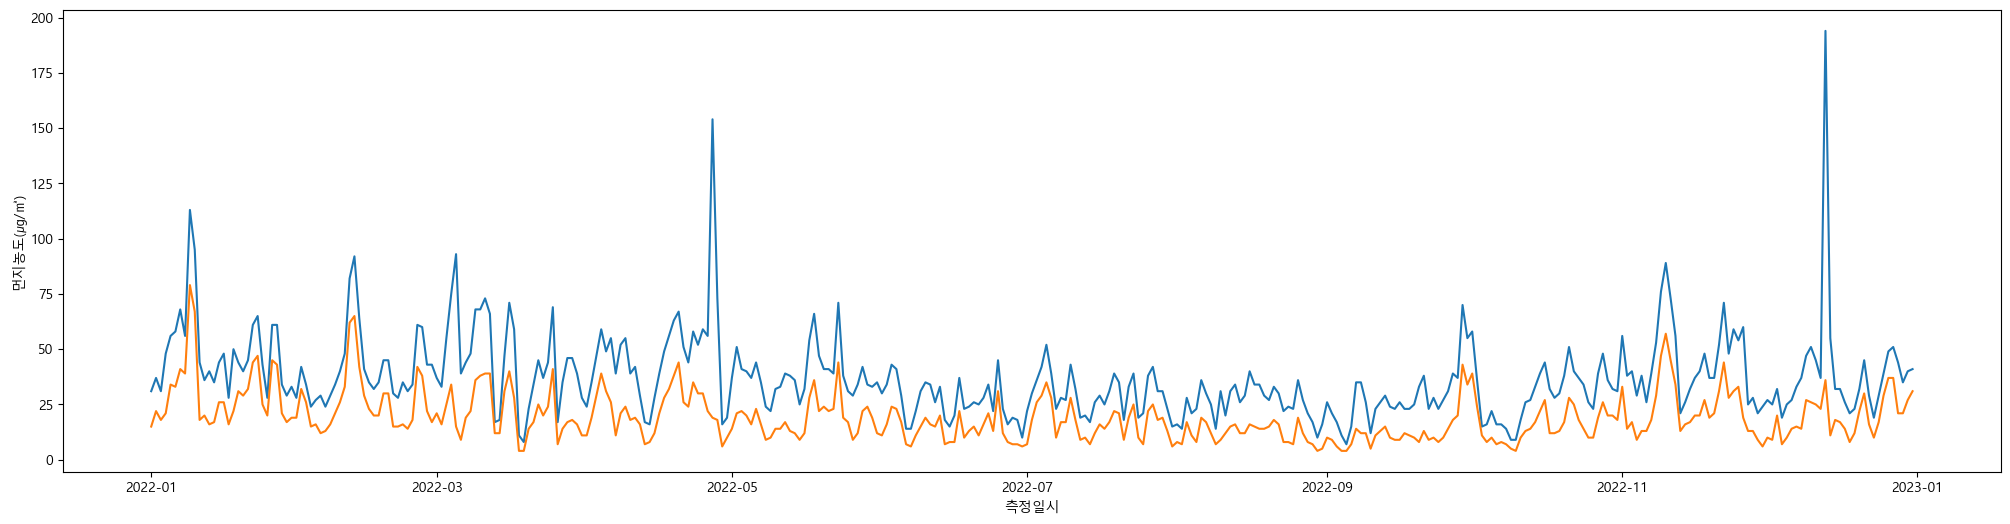

In [59]:
plt.figure(figsize=(25,6))
plt.plot(df_flt['측정일시'], df_flt['미세먼지농도(㎍/㎥)'], label='미세먼지농도')
plt.plot(df_flt['측정일시'], df_flt['초미세먼지농도(㎍/㎥)'], label='초미세먼지농도')
plt.xlabel('측정일시')
plt.ylabel('먼지농도(㎍/㎥)')
plt.show()

# statsmodels를 통한 추이 탐색
- pip install statsmodels==0.13.5
- 주기적인 데이터의 트렌드 추이
- 날짜형인덱스와 데이터 컬럼

In [60]:
df_flt2 = df_flt[['측정일시','미세먼지농도(㎍/㎥)']]
ts = df_flt2.set_index('측정일시')
ts.head()

,미세먼지농도(㎍/㎥)
측정일시,
2022-01-01,31.0
2022-01-02,37.0
2022-01-03,31.0
2022-01-04,48.0
2022-01-05,56.0


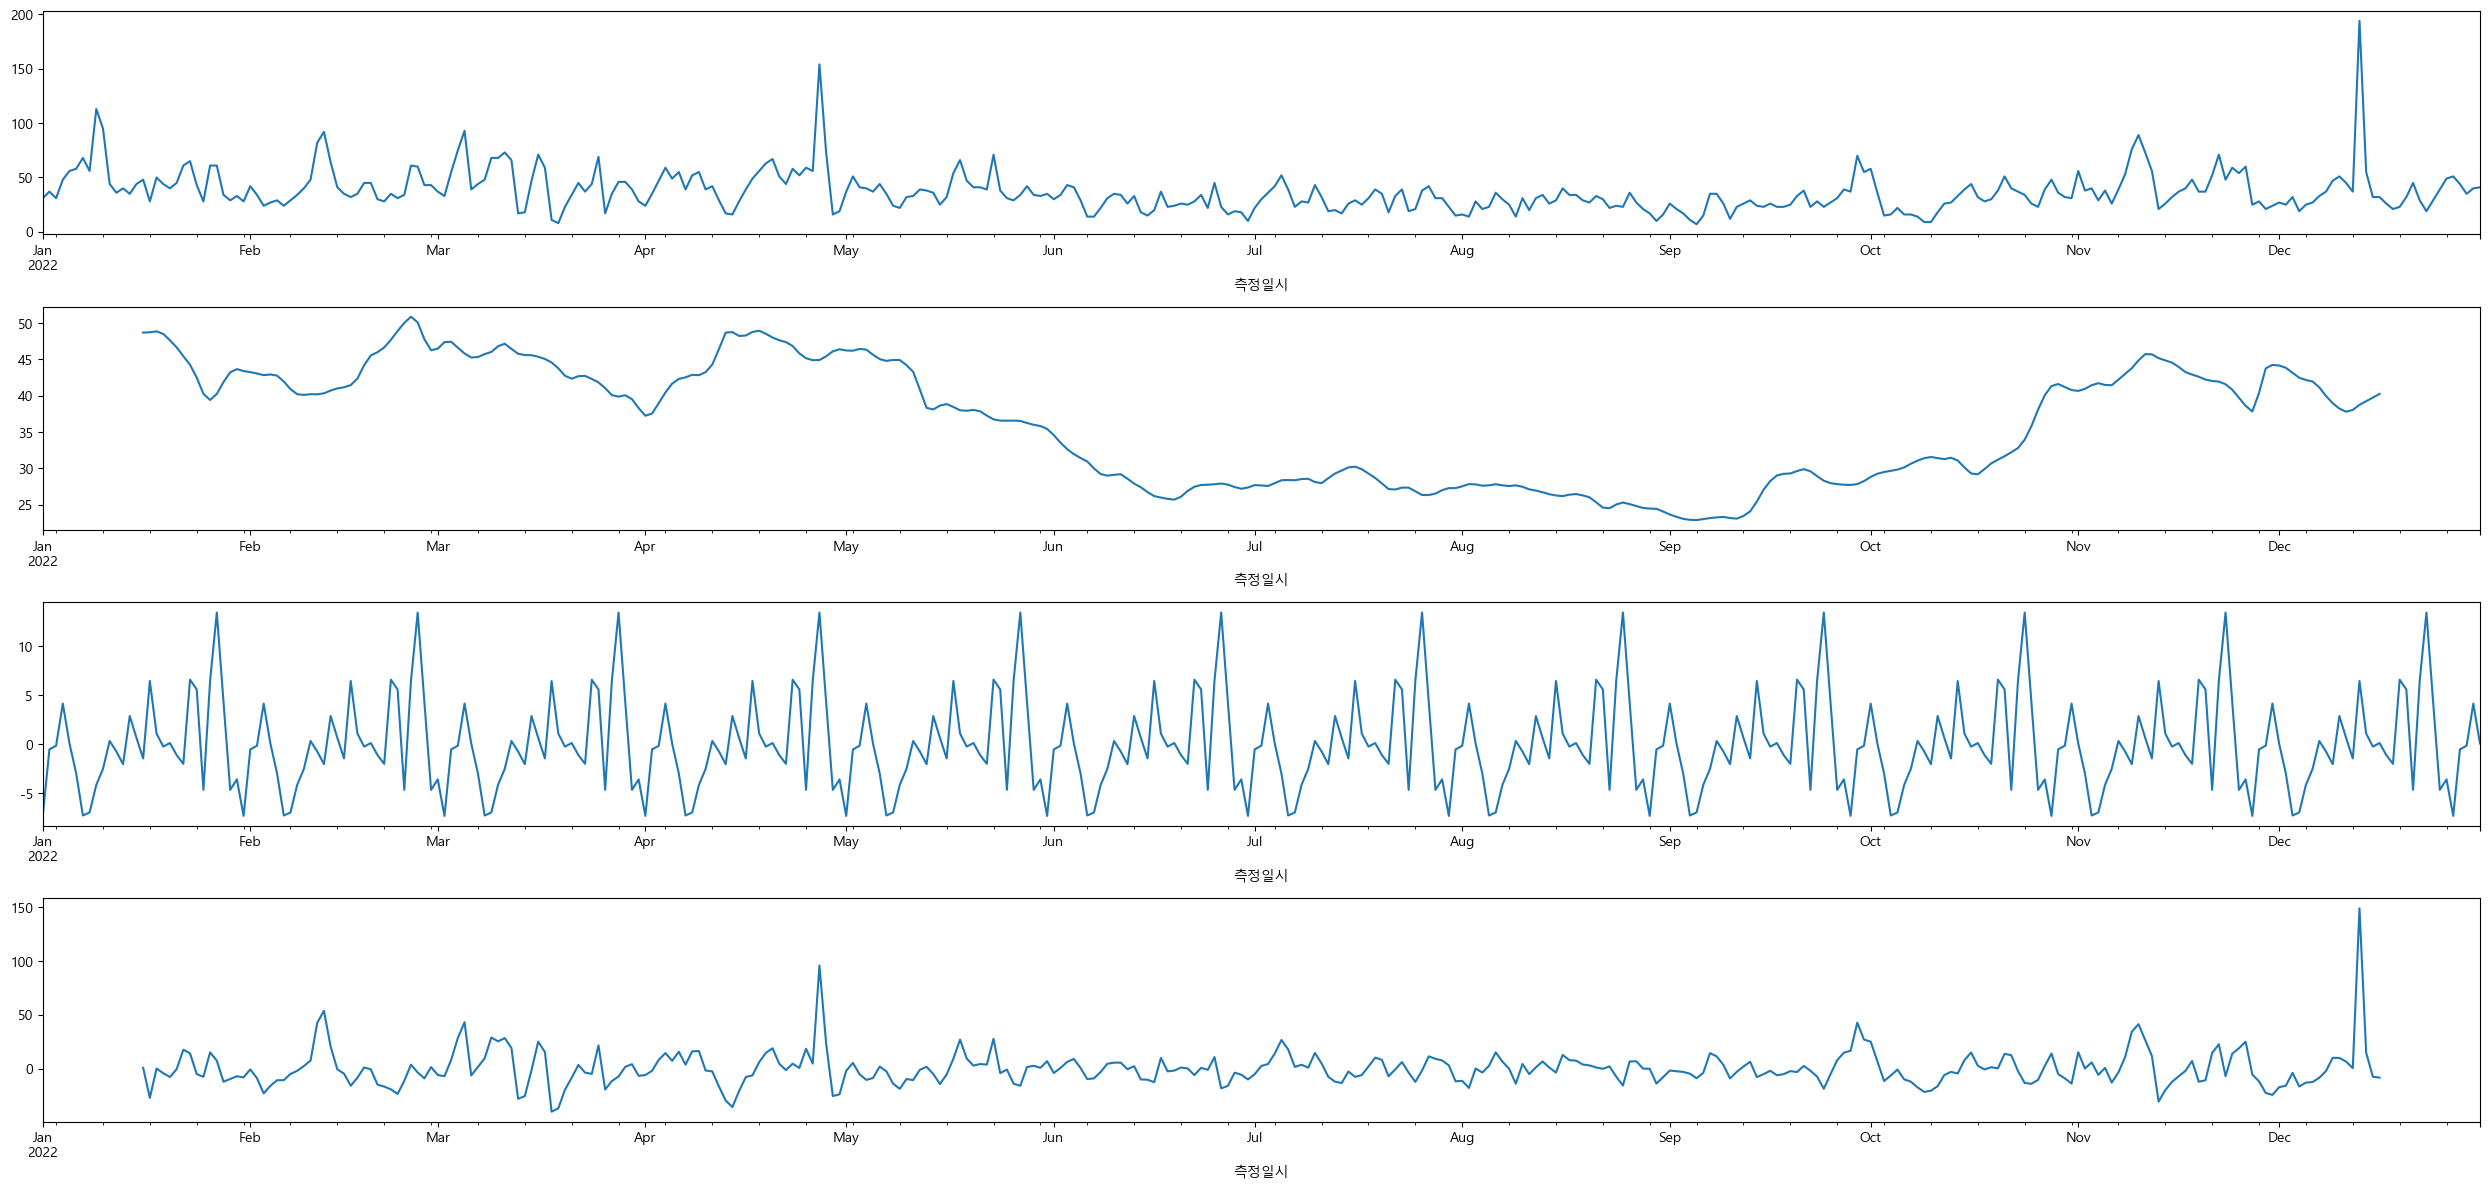

In [71]:
# 시계열 데이터의 구조를 분해 해주는 도구(statsmodels.tsa 시계열 분석 lib 패키지)
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ts['미세먼지농도(㎍/㎥)'],
                           period=30, # 30일 단위로 계절성을 분해하여 해석 / 인덱스가 날짜형이여야함
                           model='additive' # "실제값 = 추세+계절성+잔차"식으로 분석
                           )
# result.observed : 실제 데이터
# result.trend # 데이터의 장기적인 변화. 전반적으로 감소, 증가
# result.seasonal # 주기적인 계절성 패턴
# result.resid # 잔차(실제값에서 추세와 계절성을 뺀 노이즈)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(25, 12))
result.observed.plot(ax=axes[0])
result.trend.plot(ax=axes[1])
result.seasonal.plot(ax=axes[2])
result.resid.plot(ax=axes[3])
# axes[0].plot(result.observed)
# axes[1].plot(result.trend)
# axes[2].plot(result.seasonal)
# axes[3].plot(result.resid)
plt.tight_layout()
plt.show()

```
    통계적 추이 분석             예측                추이&예측
    seasonal_decompose & RNN/LSTM/GRU/Seq2Seq & Prophet
```
# Prophet
- 계절성, 추이, 휴일효과 등을 자동으로 모델링(facebook에서 개발한 시계열 예측 라이브러리)
- pip install prophet

In [72]:
df_flt2.sample()

,측정일시,미세먼지농도(㎍/㎥)
17394,2022-12-14,55.0


In [73]:
df_flt2.columns = ['ds', 'y'] # prophet 학습시 컬럼명을 ds,y로 해야 됨
df_flt2.sample()

,ds,y
6045,2022-05-01,37.0


In [74]:
df_flt2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      365 non-null    datetime64[ns]
 1   y       365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.6 KB


In [75]:
from prophet import Prophet
# 1. 모델 생성
p_model = Prophet()

# 2. 모델 학습
p_model.fit(df_flt2)

14:50:30 - cmdstanpy - INFO - Chain [1] start processing
14:50:30 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,2022-01-01
1,2022-01-02
2,2022-01-03
3,2022-01-04
4,2022-01-05
...,...
390,2023-01-26
391,2023-01-27
392,2023-01-28
393,2023-01-29


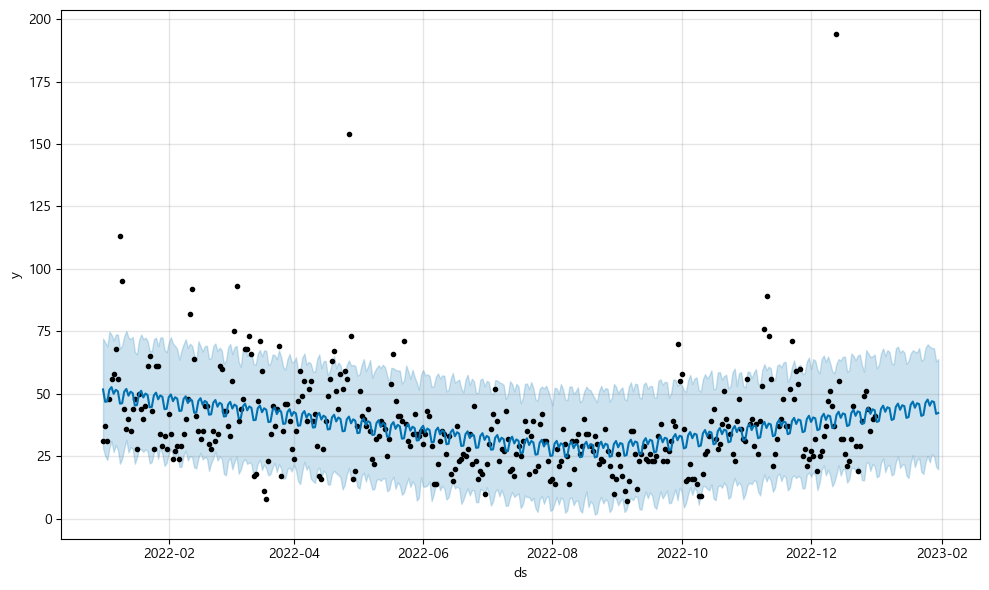

In [86]:
# p_model을 이용하여 30일 이후의 데이터를 예측하고 추이
# 3. 미래 데이터 프레임을 생성(30일 예측)
future = p_model.make_future_dataframe(periods=30)
display(future)

# 4. 예측 수행
forecast = p_model.predict(future)

# 5. 시각화
p = p_model.plot(forecast) # 그래프를 한번만 그리려면 할당

In [93]:
forecast[ ['ds', 'yhat_lower', 'yhat_upper', 'trend'] ].tail(30)
# forecast : yhat을 추세+계절성+기타요인

,ds,yhat_lower,yhat_upper,trend
365,2023-01-01,16.623148,60.277560,42.364377
366,2023-01-02,17.161057,61.515858,42.480559
367,2023-01-03,22.357510,66.255535,42.596742
368,2023-01-04,24.200262,68.210618,42.712924
369,2023-01-05,18.725709,65.151444,42.829107
370,2023-01-06,21.183936,67.537051,42.945289
371,2023-01-07,21.515700,66.812697,43.061471
372,2023-01-08,17.348881,62.409603,43.177654
373,2023-01-09,18.015131,61.762158,43.293836
374,2023-01-10,22.750532,68.227939,43.410018


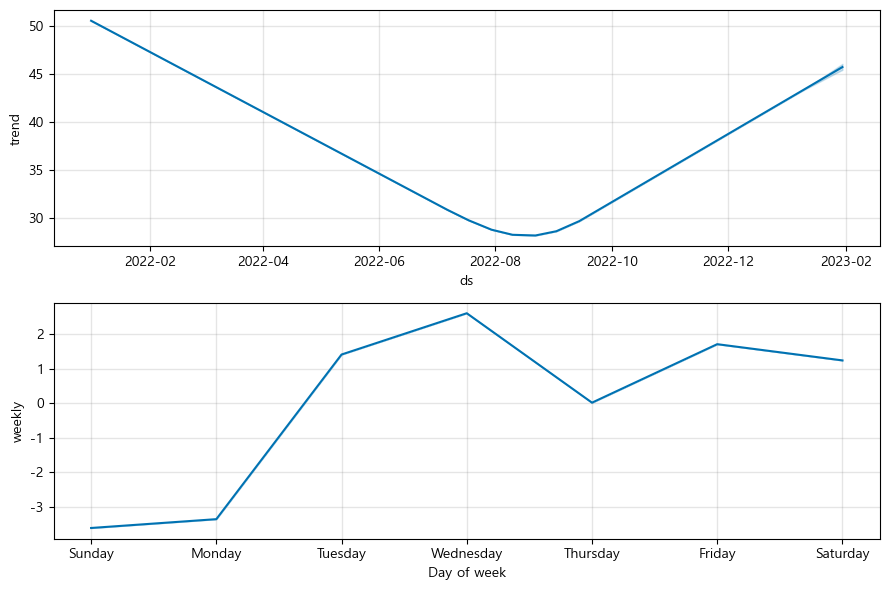

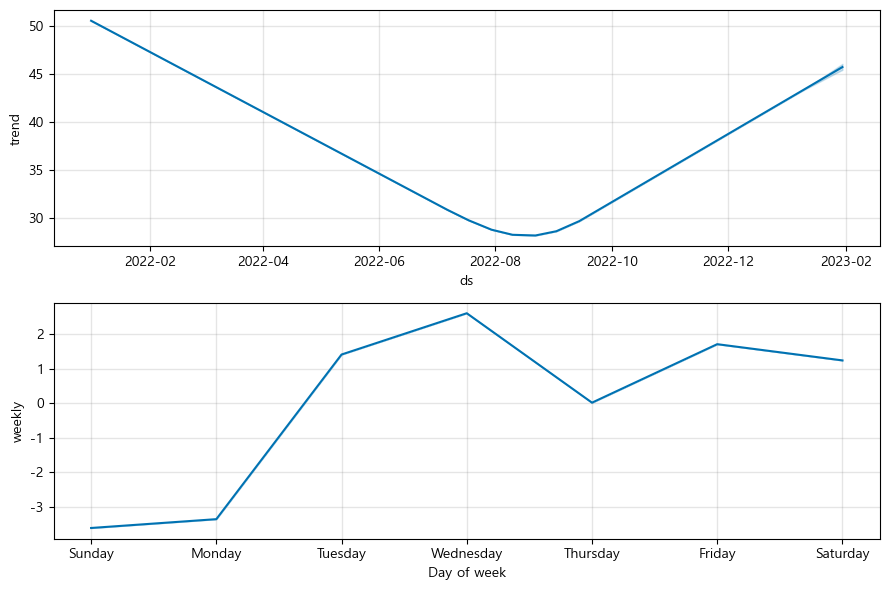

In [99]:
# 트렌드와 휴일효과 시각화
p_model.plot_components(forecast)

In [100]:
forecast.loc[forecast['ds']=='2023=01-15', ['yhat', 'yhat_lower', 'yhat_upper'] ]

,yhat,yhat_lower,yhat_upper
